In [ ]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.tn import ContinuousVar
from calibrated_response.maxent_sampler import (
    SamplerModel, moment, product, soft_gt, hard_gt, plot_pairwise)

In [ ]:
NV = 3
lo = [0.0] * NV
hi = [1.0] * NV
vars = [ContinuousVar(f"x{i}", float(lo[i]), float(hi[i]), 32) for i in range(NV)]
constr_list = [
    ("expect", moment(0, 1), 0.5, 4.0),
    ("expect", moment(1, 1), 0.5, 4.0),
    ("expect", moment(2, 1), 0.5, 4.0),
]
# weight_reg is the wrong regulariser here: theta -> 0 gives the constant sample
# x = sigmoid(0) = 0.5, which satisfies every mean constraint exactly — so the
# L2-regularised optimum is a point mass.  entropy_reg (soft-histogram marginal
# entropy) rewards spread instead, and pair_entropy_reg scores 2-D pair
# marginals so the joint can't collapse onto a curve with uniform 1-D marginals.
# The maxent fit here is independent uniforms.
# sm_h = SamplerModel(vars, latent_dim=64, hidden_sizes=[128, 128, 128, 128])
# p_h, hist_h = sm_h.optimize(
#     sm_h.constraint_loss(constr_list, n_samples=2000,
#                          entropy_reg=0.1, pair_entropy_reg=0.1),
#     backend="adam", steps=3000, lr=0.01)
# x_fit = sm_h.sample(p_h, 20000, seed=1)
# for i in range(NV):
#     print(f"x{i}: mean={x_fit[:, i].mean():.4f}  sd={x_fit[:, i].std():.4f}"
#           f"   (uniform sd = {1 / np.sqrt(12):.3f})")
# print("corr:\n", np.round(np.corrcoef(x_fit.T), 3))
# sites = [0, 1, 2]
# _FIG3 = plot_pairwise(sm_h, p_h, sites=sites, names=[f"x{i}" for i in sites],
#                       n_samples=90000, seed=1, bins=100)[0]

x0: mean=0.5024  sd=0.2820   (uniform sd = 0.289)
x1: mean=0.5063  sd=0.2788   (uniform sd = 0.289)
x2: mean=0.5054  sd=0.2839   (uniform sd = 0.289)
corr:
 [[ 1.    -0.015  0.013]
 [-0.015  1.    -0.015]
 [ 0.013 -0.015  1.   ]]


In [ ]:
net = sm_h.net
import jax
key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
z = jax.random.normal(k1, (net.latent_dim,))
params = net.init_params(k2)
samples = net.sample_fn_pytree(params, z)
print(samples)

[0.56878996 0.47163725 0.43905485]


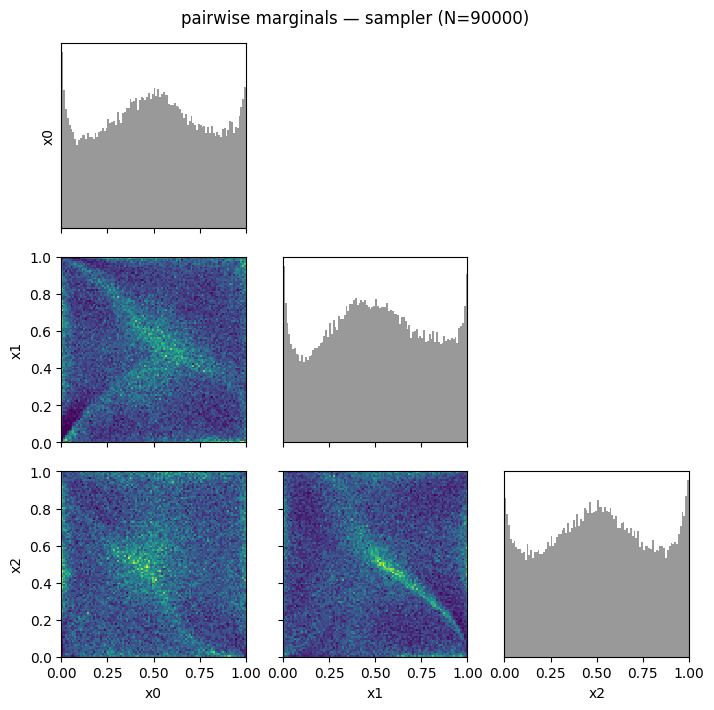

## Flow sampler — exact joint entropy

The histogram proxies above only guard 1-D (and optionally 2-D) marginals, so the
joint can still hide degeneracy at higher orders. `FlowSamplerModel` makes the
sampler *invertible* (affine coupling layers, `latent_dim = n_vars`), so the joint
entropy is **exact** via the change of variables `H(x) = H(z) + E[log|det J|]` —
computed in O(D) per sample, no bins, ungameable (mass on any lower-dimensional
manifold has `H = -inf`). With `entropy_reg=1.0` the loss is a true
soft-constrained maxent objective.

In [ ]:
from calibrated_response.maxent_sampler import FlowSamplerModel

fm = FlowSamplerModel(vars, n_layers=8, hidden=64)
p_f, hist_f = fm.optimize(
    fm.constraint_loss(constr_list, n_samples=2000, entropy_reg=1.0),
    backend="adam", steps=3000, lr=1e-3)
x_flow = fm.sample(p_f, 20000, seed=1)
for i in range(NV):
    print(f"x{i}: mean={x_flow[:, i].mean():.4f}  sd={x_flow[:, i].std():.4f}"
          f"   (uniform sd = {1 / np.sqrt(12):.3f})")
print("corr:\n", np.round(np.corrcoef(x_flow.T), 3))
print(f"exact H(x) = {fm.entropy(p_f):.4f} nats   (independent uniform -> 0.0)")

x0: mean=0.5002  sd=0.2933   (uniform sd = 0.289)
x1: mean=0.4988  sd=0.2849   (uniform sd = 0.289)
x2: mean=0.5047  sd=0.2849   (uniform sd = 0.289)
corr:
 [[ 1.    -0.008 -0.002]
 [-0.008  1.     0.028]
 [-0.002  0.028  1.   ]]


exact H(x) = -0.0076 nats   (independent uniform -> 0.0)


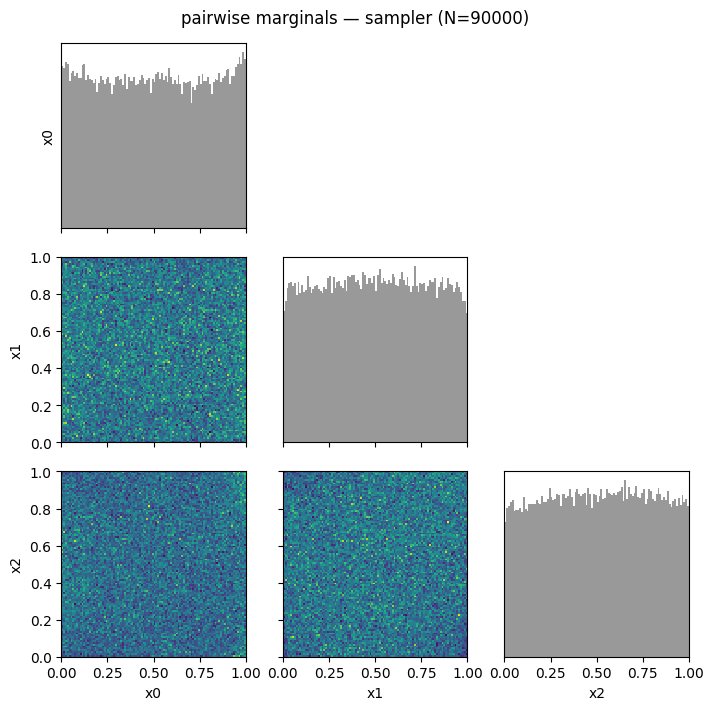

In [6]:
_FIG4 = plot_pairwise(fm, p_f, sites=sites, names=[f"x{i}" for i in sites],
                      n_samples=90000, seed=1, bins=100)[0]

## 30 variables — scalability check

Same flow model at 30 variables on `[0,100]`: mean constraints on every variable
plus `E[x_i x_{i+1}] = 2800` on ten adjacent pairs (⇒ corr ≈ 0.36 given uniform
sds). The loss is built with `resample=True` (the flow-model default): a fresh z
batch is drawn every optimizer step, so the flow cannot overfit a fixed batch
(with a fixed batch it learns to place exactly those `z_i` at high `log|det J|`
while the *true* entropy collapses — fresh-sample H was −1659 in that failure
mode; with resampling it lands within a few nats of the independence maximum
`30·log 100 ≈ 138.2`).

Two things worth noticing:
- **Compile time is constant** in the number of variables (fixed layer count) —
  ~8s here vs the minutes-long unrolled-constraint compiles elsewhere.
- Maxent finds the *cheapest* explanation: with loose mean constraints
  (`value_sd=5`) the model satisfied `E[xy]=2800` by shifting means to 53
  (53² ≈ 2809) instead of correlating. The means below are pinned with
  `value_sd=1`, which forces genuine correlation.

In [ ]:
NV30 = 30
vars30 = [ContinuousVar(f"x{i}", 0.0, 100.0, 32) for i in range(NV30)]
cons30 = (
    [("expect", moment(i, 1), 50.0, 1.0 / (2 * 1.0**2)) for i in range(NV30)]
    + [("expect", product(i, i + 1), 2800.0, 1.0 / (2 * 100.0**2)) for i in range(NV30 - 1)]
)

fm30 = FlowSamplerModel(vars30, n_layers=8, hidden=128)
p_30, hist_30 = fm30.optimize(
    fm30.constraint_loss(cons30, n_samples=1024, entropy_reg=1.0),  # resample=True default
    backend="adam", steps=3000, lr=1e-3)

x30 = fm30.sample(p_30, 20000, seed=99)
C30 = np.corrcoef(x30.T)
rc = [C30[i, i + 1] for i in range(10)]
ru = [C30[i, i + 1] for i in range(15, 25)]
exy = np.mean([np.mean(x30[:, i] * x30[:, i + 1]) for i in range(10)])
print(f"means in [{x30.mean(0).min():.1f}, {x30.mean(0).max():.1f}]   (target 50)")
print(f"sds   in [{x30.std(0).min():.1f}, {x30.std(0).max():.1f}]   (uniform = 28.9)")
print(f"constrained pairs:   corr {np.mean(rc):.3f} in [{min(rc):.2f}, {max(rc):.2f}],"
      f"  E[xy] = {exy:.0f}  (target 2800)")
print(f"unconstrained pairs: corr {np.mean(ru):.3f}")
print(f"exact H(x) on fresh samples = {fm30.entropy(p_30, seed=123):.1f}"
      f"   (independent uniform = {NV30 * np.log(100):.1f})")

means in [49.7, 50.5]   (target 50)
sds   in [21.1, 28.8]   (uniform = 28.9)
constrained pairs:   corr 0.395 in [0.37, 0.42],  E[xy] = 2787  (target 2800)
unconstrained pairs: corr 0.003


exact H(x) on fresh samples = 132.9   (independent uniform = 138.2)


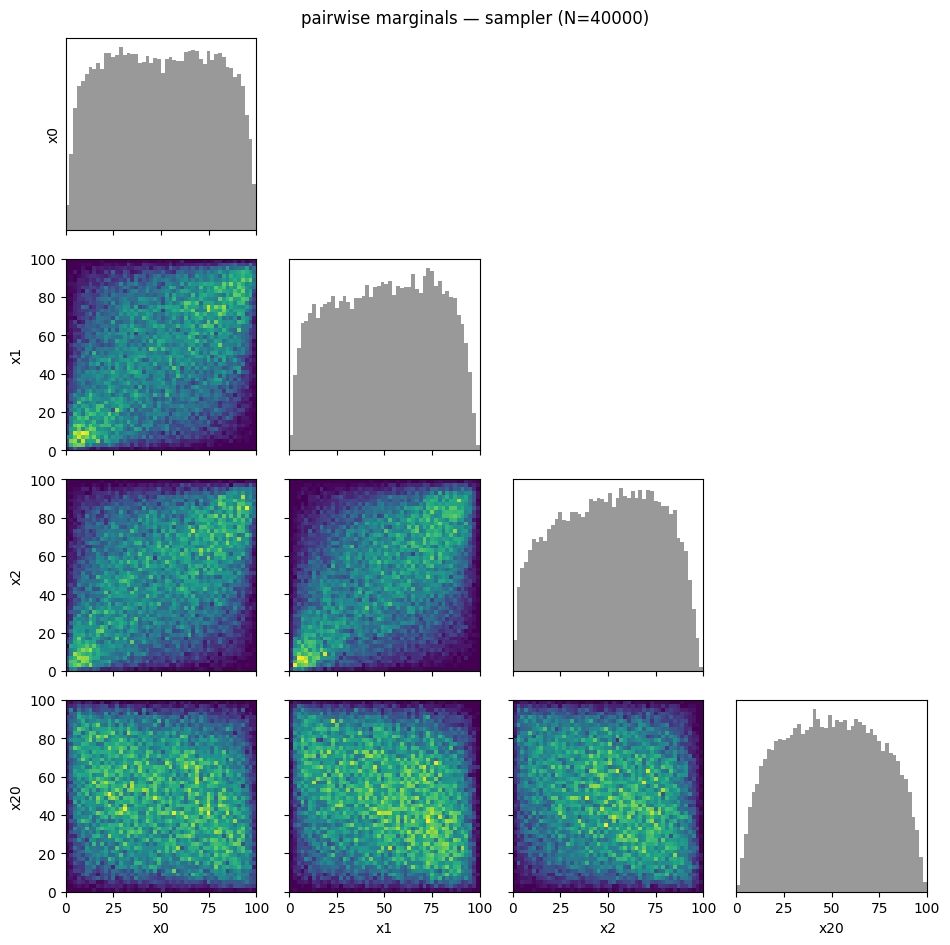

In [8]:
# corner plot over two constrained pairs (0,1), (1,2) and one unconstrained var
_FIG5 = plot_pairwise(fm30, p_30, sites=[0, 1, 2, 20],
                      names=["x0", "x1", "x2", "x20"],
                      n_samples=40000, seed=99, bins=50)[0]